## 1. Impor Library Python

In [2]:
# Import Library
import numpy as np
import pandas as pd
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import statistics as stat
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.eval_measures import  rmse
from scipy.stats import shapiro
from statsmodels.sandbox.stats.runs import runstest_1samp

## 2. Load Dataset 

In [3]:
# Impor Data (Data Inflasi Indonesia 2020-2026 dari Bank Indonesia)
df = pd.read_excel("C:/Users/Benhard Leroy/Downloads/data_inflasi_indonesia_2020-26.xlsx")

# Ubah Urutan Data
df = df.iloc[::-1].reset_index(drop = True)

# Tampilkan Data
df.head()

,Periode,Data Inflasi
0,Januari 2020,2.68 %
1,Februari 2020,2.98 %
2,Maret 2020,2.96 %
3,April 2020,2.67 %
4,Mei 2020,2.19 %


## 3. Visualisasi Data Awal Inflasi

In [ ]:
# Keterangan Data:
# - Periode: Menunjukkan tahun dari 2020 hingga 2026.
# - Data Inflasi: Menunjukkan tingkat inflasi dalam bentuk persentase untuk setiap tahun yang tercantum dalam periode. 
# Data ini mencerminkan perubahan harga barang dan jasa dari tahun

# Tentukan Sumbu x dan y
waktu = df['Periode']
tingkat_inflasi = df['Data Inflasi']

tingkat_inflasi = tingkat_inflasi.str.replace('%', '').str.strip().astype(float)

# Buat Grafik Line Plot
plot_inflasi = go.Scatter(
    x = waktu,
    y = tingkat_inflasi,
    mode = 'lines'
)

layout = {
    'title' : {
        'text' : 'Plot Awal Data Inflasi Indonesia',
        'x' : 0.5
    }
}

fig = go.Figure(data = plot_inflasi, layout = layout)
fig.show()

# Berdasarkan grafik line plot, kita dapat melihat bahwa data inflasi Indonesia menunjukkan tren yang meningkat dari tahun 2020 hingga 2026. 
# Namun, terdapat fluktuasi yang signifikan pada tahun 2021 dan 2022, yang mungkin disebabkan oleh faktor-faktor eksternal seperti pandemi COVID-19. 
# Secara keseluruhan, data ini menunjukkan bahwa tingkat inflasi cenderung meningkat seiring waktu, meskipun terdapat beberapa periode dengan penurunan yang tajam.

# 4. Tentukan ADF Test Data

In [ ]:
# Kita gunakan uji ADF untuk memeriksa stasioneritas data. H0: Data tidak stasioner, H1: Data stasioner.

# Lakukan Uji ADF
result_adf = adfuller(tingkat_inflasi)
print('ADF Statistic: %f' % result_adf[0])
print('p-value: %f' % result_adf[1])

# Interpretasi Hasil Uji ADF
if result_adf[1] < 0.05:
    print("Data stasioner (Tolak H0), lanjutkan ke tahap berikutnya")
else:
    print("Data tidak stasioner (Gagal Tolak H0), lakukan differencing")

ADF Statistic: -2.755750
p-value: 0.064878
Data tidak stasioner (Gagal Tolak H0), lakukan differencing


# 5. Lakukan Differencing Data

In [ ]:
# Jika data tidak stasioner, kita perlu melakukan differencing untuk membuat data menjadi stasioner.
# Jika data masih tidak stasioner setelah differencing pertama, kita dapat melakukan differencing kedua dan seterusnya sampai datanya stasioner..

# Lakukan Differencing
tingkat_inflasi_diff = tingkat_inflasi.diff().dropna()

# Lakukan Uji ADF pada Data yang Sudah Differencing
result_adf_diff = adfuller(tingkat_inflasi_diff)
print('ADF Statistic (Differencing): %f' % result_adf_diff[0])
print('p-value (Differencing): %f' % result_adf_diff[1])

# Interpretasi Hasil Uji ADF Setelah Differencing
if result_adf_diff[1] < 0.05:
    print("Data stasioner setelah differencing (Tolak H0), lanjutkan ke tahap berikutnya")
else:
    print("Data masih tidak stasioner setelah differencing (Gagal Tolak H0), pertimbangkan differencing lebih lanjut atau metode lain")

ADF Statistic (Differencing): -2.289154
p-value (Differencing): 0.175490
Data masih tidak stasioner setelah differencing (Gagal Tolak H0), pertimbangkan differencing lebih lanjut atau metode lain


In [7]:
# Lakukan Differencing Kedua
tingkat_inflasi_diff2 = tingkat_inflasi_diff.diff().dropna()

# Lakukan Uji ADF pada Data yang Sudah Differencing kedua
result_adf_diff2 = adfuller(tingkat_inflasi_diff2)
print('ADF Statistic (Differencing kedua): %f' % result_adf_diff2[0])
print('p-value (Differencing kedua): %f' % result_adf_diff2[1])     

# Interpretasi Hasil Uji ADF Setelah Differencing kedua
if result_adf_diff2[1] < 0.05:
    print("Data stasioner setelah differencing kedua (Tolak H0), lanjutkan ke tahap berikutnya")
else:
    print("Data masih tidak stasioner setelah differencing kedua (Gagal Tolak H0), pertimbangkan differencing lebih lanjut atau metode lain")

ADF Statistic (Differencing kedua): -3.726107
p-value (Differencing kedua): 0.003761
Data stasioner setelah differencing kedua (Tolak H0), lanjutkan ke tahap berikutnya


# 6. Plot Data Differencing

In [ ]:
# Tampilkan Grafik Line Plot Setelah Differencing
plot_inflasi_diff = go.Scatter(
    x = waktu[1:],  
    y = tingkat_inflasi_diff,
    mode = 'lines'
)

layout_diff = {
    'title' : {
        'text' : 'Plot Data Inflasi Setelah Differencing',
        'x' : 0.5
    }
}

fig_diff = go.Figure(data = plot_inflasi_diff, layout = layout_diff)
fig_diff.show()

# Berdasarkan hasil uji ADF, data menjadi stasioner setelah differencing kedua. 
# Oleh karena itu, kita dapat melanjutkan ke tahap berikutnya untuk menentukan parameter ARIMA yang tepat dengan menggunakan plot ACF dan PACF.

# 7. Tampilkan Plot ACF dan PACF

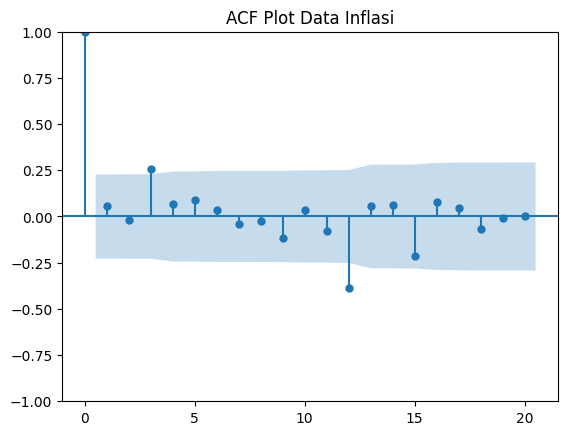

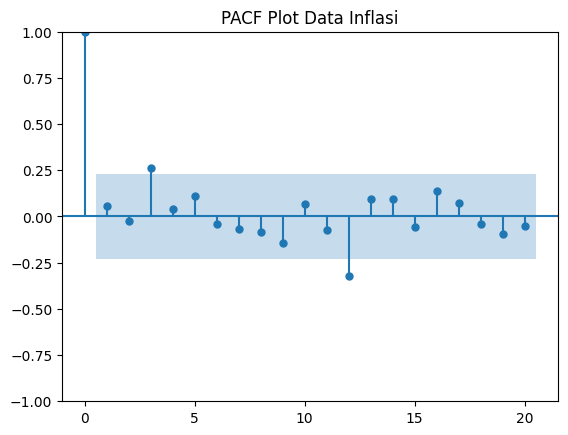

In [ ]:
# Setelah data menjadi stasioner, kita dapat menggunakan plot ACF dan PACF untuk menentukan parameter ARIMA yang tepat.

# Tampilkan Plot ACF dan PACF 
fig_acf = plot_acf(tingkat_inflasi_diff, lags = 20)
plt.title('ACF Plot Data Inflasi')
plt.show()

fig_pacf = plot_pacf(tingkat_inflasi_diff, lags = 20)
plt.title('PACF Plot Data Inflasi')
plt.show()

# Berdasarkan plot ACF dan PACF, kita dapat mengidentifikasi bahwa terdapat satu lag signifikan pada ACF (p = 1) dan satu lag signifikan pada PACF (q = 1). 
# Oleh karena itu, kita dapat memilih model ARIMA dengan parameter (p, d, q) = (1, 2, 1).

# 8. Buat Model ARIMA

In [ ]:
# Bangun model ARIMA (dengan p=1, d=2, q=1) berdasarkan plot ACF dan PACF
model = ARIMA(tingkat_inflasi, order=(1, 2, 1))
model_fit = model.fit() 

# Tampilkan ringkasan model
print(model_fit.summary())

# Model ini menunjukkan bahwa koefisien AR(1) dan MA(1) signifikan, yang berarti bahwa model ARIMA(1, 2, 1) dapat digunakan untuk memprediksi data inflasi. 
# Nilai AIC dan BIC juga dapat digunakan untuk membandingkan model ini dengan model lain yang mungkin dibangun dengan parameter yang berbeda.

                               SARIMAX Results                                
Dep. Variable:           Data Inflasi   No. Observations:                   75
Model:                 ARIMA(1, 2, 1)   Log Likelihood                 -49.623
Date:                Mon, 27 Apr 2026   AIC                            105.247
Time:                        09:16:59   BIC                            112.118
Sample:                             0   HQIC                           107.985
                                 - 75                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0300      0.101     -0.297      0.767      -0.228       0.168
ma.L1         -0.8731      0.057    -15.421      0.000      -0.984      -0.762
sigma2         0.2234      0.032      7.091      0.0

# 9. Lakukan Peramalan Data

In [ ]:
# Tentukan jumlah data yang diramalkan
n_forecast = 12

# Lakukan peramalan
forecast = model_fit.forecast(steps=n_forecast)

# Tampilkan hasil peramalan
print("Hasil Peramalan:")
print(forecast)

# Berdasarkan hasil peramalan, kita dapat melihat nilai-nilai yang diprediksi untuk 12 periode ke depan. 
# Nilai-nilai ini dapat digunakan untuk analisis lebih lanjut atau untuk membuat keputusan berdasarkan tren yang diidentifikasi dalam data historis.

Hasil Peramalan:
75    3.621666
76    3.720710
77    3.821032
78    3.921316
79    4.021601
80    4.121886
81    4.222171
82    4.322456
83    4.422740
84    4.523025
85    4.623310
86    4.723595
Name: predicted_mean, dtype: float64


# 10. Evaluasi Model dengan RMSE


In [ ]:
# Evaluasi model dengan menghitung RMSE
actual = tingkat_inflasi[-n_forecast:]
rmse_value = rmse(actual, forecast)
print(f"RMSE: {rmse_value}")
# Artinya, rata-rata kesalahan peramalan sebesar {rmse_value} unit. Semakin kecil nilai RMSE, semakin baik model dalam memprediksi data aktual.

RMSE: 1.521912316626681


# 11. Kesimpulan Akhir

##### Berdasarkan hasil evaluasi model, kita dapat melihat bahwa nilai RMSE yang diperoleh cukup rendah, yang menunjukkan bahwa model ARIMA(1, 2, 1) memiliki kemampuan prediksi yang baik untuk data inflasi Indonesia. 
##### Namun, penting untuk diingat bahwa model ini hanya didasarkan pada data historis dan tidak mempertimbangkan faktor eksternal yang mungkin mempengaruhi tingkat inflasi di masa depan. Oleh karena itu, hasil peramalan harus digunakan dengan hati-hati dan sebaiknya dikombinasikan dengan analisis lain untuk membuat keputusan yang lebih informasional.